In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna()

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
features = penguins.drop(columns=["species", "island", "sex"])

In [5]:
target = penguins["body_mass_g"]

In [6]:
features = features.drop(columns=["body_mass_g"]) # we may want to first "forget" to do this, so that we can show learners what it looks like in the results (perfect predictions)

In [7]:
target

0      3750.0
1      3800.0
2      3250.0
4      3450.0
5      3650.0
        ...  
338    4925.0
340    4850.0
341    5750.0
342    5200.0
343    5400.0
Name: body_mass_g, Length: 333, dtype: float64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0, shuffle=True)

In [9]:
body_mass_predictor = RandomForestRegressor()


In [10]:
body_mass_predictor.fit(X=X_train, y=y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
predicted_masses = body_mass_predictor.predict(X_test)
true_masses = y_test

In [12]:
dir(metrics)

['ConfusionMatrixDisplay',
 'DetCurveDisplay',
 'DistanceMetric',
 'PrecisionRecallDisplay',
 'PredictionErrorDisplay',
 'RocCurveDisplay',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_classification',
 '_dist_metrics',
 '_pairwise_distances_reduction',
 '_pairwise_fast',
 '_plot',
 '_ranking',
 '_regression',
 '_scorer',
 'accuracy_score',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'auc',
 'average_precision_score',
 'balanced_accuracy_score',
 'brier_score_loss',
 'calinski_harabasz_score',
 'check_scoring',
 'class_likelihood_ratios',
 'classification_report',
 'cluster',
 'cohen_kappa_score',
 'completeness_score',
 'confusion_matrix',
 'confusion_matrix_at_thresholds',
 'consensus_score',
 'coverage_error',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'd2_pinball_score',
 'd2_tweedie_score',
 'davies_bouldin_score',
 'dcg_score',
 'det_cu

In [13]:
from sklearn.metrics import root_mean_squared_error

In [14]:
# for next time: is it worthwhile discussing choice of metric further? E.g. should we use mean abs error?
#   Squared error would penalise the outliers more heavily.
# next time, we will pick up from here, to evaluate the trained model, discuss whether to re-introduce
# (some of) the columns we excluded before: factors like sex, species that probably have predictive value for body mass.

In [15]:
# 2026/08/24

Text(0, 0.5, 'predicted_masses')

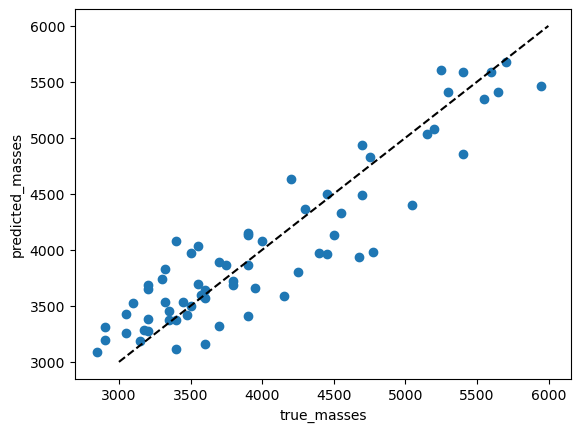

In [16]:
import matplotlib.pyplot as plt
plt.scatter(true_masses, predicted_masses)
plt.plot(np.arange(3000,6000), np.arange(3000,6000), "k--")
plt.xlabel("true_masses")
plt.ylabel("predicted_masses")

In [17]:
# re-introducing categorical columns will require some encoding
# ordinal encoding may not be the right thing because of the way decision trees work (introduces ordering of labels that may not be there to begin with)
# so maybe one-hot encoding it is

In [18]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [19]:
# convert all categorical columns to one-hot
penguins_oh = pd.get_dummies(penguins, columns=['species', 'island', 'sex'], dtype=int)
penguins_oh

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
0,39.1,18.7,181.0,3750.0,1,0,0,0,0,1,0,1
1,39.5,17.4,186.0,3800.0,1,0,0,0,0,1,1,0
2,40.3,18.0,195.0,3250.0,1,0,0,0,0,1,1,0
4,36.7,19.3,193.0,3450.0,1,0,0,0,0,1,1,0
5,39.3,20.6,190.0,3650.0,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,0,0,1,1,0,0,1,0
340,46.8,14.3,215.0,4850.0,0,0,1,1,0,0,1,0
341,50.4,15.7,222.0,5750.0,0,0,1,1,0,0,0,1
342,45.2,14.8,212.0,5200.0,0,0,1,1,0,0,1,0


In [20]:
features = penguins_oh.drop(columns=["body_mass_g"])
target = penguins_oh["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0, shuffle=True)

body_mass_predictor = RandomForestRegressor()
body_mass_predictor.fit(X=X_train, y=y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
predicted_masses = body_mass_predictor.predict(X_test)
true_masses = y_test

Text(0, 0.5, 'predicted_masses')

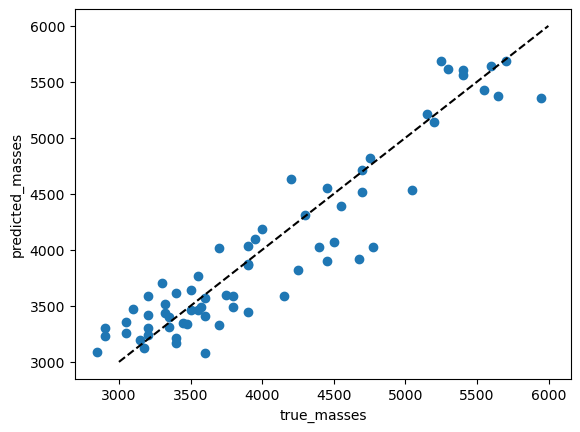

In [22]:
import matplotlib.pyplot as plt
plt.scatter(true_masses, predicted_masses)
plt.plot(np.arange(3000,6000), np.arange(3000,6000), "k--")
plt.xlabel("true_masses")
plt.ylabel("predicted_masses")

In [24]:
# possible metrics, printed below
# RMSE root mean square error
# MAE mean absolute error
# R² Score
# MAPE Mean Absolute Percentage Error
# (we could later discuss cross-validation during training and Out-of-Bag (OOB) Error?)
# Error measures computed below.

In [25]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [26]:
root_mean_squared_error(predicted_masses, true_masses) # units of gram (root of square "cancels")

295.9600980946234

In [27]:
mean_absolute_error(predicted_masses, true_masses) # units of gram

233.58582089552237

In [28]:
mean_absolute_percentage_error(predicted_masses, true_masses)

0.06052748165550351

In [29]:
r2_score(predicted_masses, true_masses)

0.857315215584058

In [29]:
# is there a good way to visualize these error measures?

We think it could be good to cover cross-validation at the end of this episode already. The cognitive load of this episode has been relatively small so far, since we are using the same data and type of method (RF) again.
Counterpoint could be, that cross-validation of a model trained with no hyperparameters is not particularly interesting. That might be fine for this first simple example but we would definitely want to show a more realistic and useful case for cross-validation before the end of the lesson.

We could use [sklearn's functions for cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html), which would be easy but might hide too much of the mechanics of what's really going on to be a good teaching experience. The alternative would be to do the steps manually. 

Following the steps from the linked sklearn tutorial...

In [30]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(body_mass_predictor, X_train, y_train, cv=5)

In [32]:
print("%0.2f accuracy with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

0.84 accuracy with a standard deviation of 0.05


My immediate reaction is that this is indeed a bit boring and opaque. If we don't want to take the steps manually, we would need a good illustration here that will help learners understand what is happening.

Showing the data in each _fold_ (the subsamples of the data used for cross-validation) would help learners grasp what is happening each time. Simpler option: show the 'head' of the data table for each fold, highlighting that different rows appear in each fold. More complicated: plot boxplots to show and compare the distribution of data points in each fold. Regardless of which approach we take, an illustration of the cross-validation process would be valuable here.

In [50]:
# taking the cross-validation steps manually
from sklearn.model_selection import ShuffleSplit
ss = ShuffleSplit(n_splits=5, test_size=0.25, random_state=0)
for training_rows, test_rows in ss.split(features.head(10)):
    print("%s %s" % (training_rows, test_rows))

[9 1 6 7 3 0 5] [2 8 4]
[2 9 8 0 6 7 4] [3 5 1]
[4 5 1 0 6 9 7] [2 3 8]
[2 7 5 8 0 3 4] [6 1 9]
[4 1 0 6 8 9 3] [5 2 7]


In [52]:
features.loc[[0, 13]]

,bill_length_mm,bill_depth_mm,flipper_length_mm,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
0,39.1,18.7,181.0,1,0,0,0,0,1,0,1
13,38.6,21.2,191.0,1,0,0,0,0,1,0,1


In [53]:
from sklearn.model_selection import ShuffleSplit
ss = ShuffleSplit(n_splits=5, test_size=0.25, random_state=0)
for training_rows, test_rows in ss.split(features):
    X_train = features.loc[training_rows]
    X_test = features.loc[test_rows]
    y_train = target.loc[training_rows]
    y_test = target.loc[test_rows]
    body_mass_predictor = RandomForestRegressor()
    body_mass_predictor.fit(X=X_train, y=y_train)
    predicted_masses = body_mass_predictor.predict(X_test)
    true_masses = y_test
    rmse = root_mean_squared_error(predicted_masses, true_masses)
    print(f'Split 1: {rmse}')

KeyError: '[324, 3, 11, 10, 246, 286, 9, 47] not in index'

We got stuck trying to make the connection between the indices output by the shuffle-split and the sp